In [51]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [52]:
from tensorflow.keras.layers import Conv2D
from tensorflow import keras
from tensorflow.keras import layers
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report
import random
import os
from PIL import Image
import numpy as np
from tensorflow.keras import layers,models,Model
from tensorflow.keras.applications import VGG16
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.optimizers import Adam

In [53]:
#constants
main_directory = '/content/drive/MyDrive/AI 6th SEM/FruitinAmazon/FruitAmazon_extracted/FruitinAmazon/train'
test_dir = "/content/drive/MyDrive/AI 6th SEM/FruitinAmazon/FruitAmazon_extracted/FruitinAmazon/test"
img_height = 224
img_width = 224
batch_size = 32
validation_split = 0.2
num_classes = 6

In [54]:
#get the class directories from the train directory
class_directories = os.listdir(main_directory)
print(class_directories)

['pupunha', 'acai', 'guarana', 'graviola', 'tucuma', 'cupuacu']


## Task 1.1 – Visualize Images

This task involves importing necessary libraries, listing class names from the `train_dir`, and then displaying a random image from each class to get a visual understanding of the dataset.

In [55]:
random_images = []
for class_directory in class_directories:
    class_path = os.path.join(main_directory, class_directory)
    image_files = os.listdir(class_path)
    random_images.append(random.choice(image_files))
    print(f"Random image from class {class_directory}: {random_images[-1]}")

Random image from class pupunha: images (9).jpeg
Random image from class acai: images (7).jpeg
Random image from class guarana: download (1).jpeg
Random image from class graviola: images (8).jpeg
Random image from class tucuma: images.jpeg
Random image from class cupuacu: images (5).jpeg


## Task 1.2 – Remove Corrupted Images

This step iterates through all images in the training directory, attempts to open and verify them using PIL. If an image is found to be corrupted (e.g., `IOError` or `SyntaxError`), it is removed from the directory.

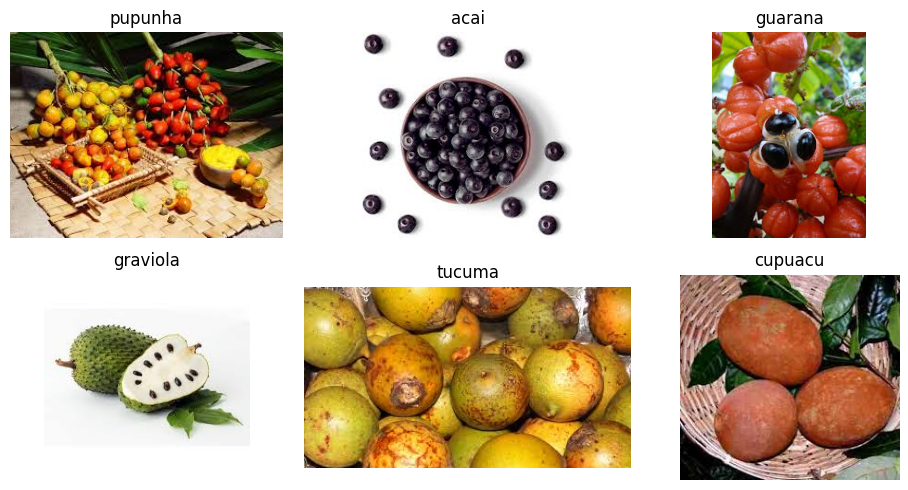

In [56]:
plt.figure(figsize=(10, 5))
for i, class_directory in enumerate(class_directories):
    class_path = os.path.join(main_directory, class_directory)
    image_files = os.listdir(class_path)
    random_image_file = random.choice(image_files)
    image_path = os.path.join(class_path, random_image_file)
    image = plt.imread(image_path)
    plt.subplot(2, len(class_directories) // 2, i + 1)
    plt.imshow(image)
    plt.title(class_directory)
    plt.axis('off')
plt.tight_layout()
plt.show()

In [57]:
import os
from PIL import Image

corrupted_images = []


print("Checking for corrupted images...")
for class_name in os.listdir(train_dir):
    class_path = os.path.join(train_dir, class_name)
    if os.path.isdir(class_path):
        for img_name in os.listdir(class_path):
            img_path = os.path.join(class_path, img_name)

            try:
                img = Image.open(img_path)
                img.verify()
            except (IOError, SyntaxError) as e:
                corrupted_images.append(img_path)
                os.remove(img_path)
                print(f"Removed corrupted image: {img_path} - Error: {e}")
            except Exception as e:
                print(f"An unexpected error occurred with {img_path}: {e}")

if len(corrupted_images) == 0:
    print("No corrupted images found.")
else:
    print(f"Found and removed {len(corrupted_images)} corrupted images.")

Checking for corrupted images...
No corrupted images found.


In [58]:
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    main_directory,
    image_size = (img_height, img_width),
    batch_size = batch_size,
    validation_split = validation_split,
    subset = "training",
    seed = 123
)


val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    main_directory,
    image_size = (img_height, img_width),
    batch_size = batch_size,
    validation_split = validation_split,
    subset = "validation",
    seed = 123
)

rescale = layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (rescale(x), y))
val_ds = val_ds.map(lambda x, y: (rescale(x), y))

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.


In [59]:
from tensorflow.keras import layers

data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.2),
])

In [60]:
model = keras.Sequential([

    layers.Input(shape=(224, 224, 3)),

    data_augmentation,

    layers.Rescaling(1./255),

    # Block 1
    layers.Conv2D(32, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.25),

    # Block 2
    layers.Conv2D(64, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.25),

    # Block 3
    layers.Conv2D(128, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.25),

    # Fully Connected
    layers.Flatten(),

    layers.Dense(256),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dropout(0.5),

    layers.Dense(len(class_names), activation='softmax')
])

In [61]:
model.compile(optimizer="adam",loss="sparse_categorical_crossentropy",metrics=["accuracy"])
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_4 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_7 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_12 (Activation)      │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_13 (Activation)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_14 (Activation)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 256)            │    25,690,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_15 (Activation)      │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 6)              │         1,54

 Total params: 25,787,078 (98.37 MB)

 Trainable params: 25,786,118 (98.37 MB)

 Non-trainable params: 960 (3.75 KB)

In [62]:
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True
    ),
    ModelCheckpoint(
        filepath='best_model.keras',
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    )
]

Epoch 1/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.2390 - loss: 2.5700
Epoch 1: val_loss improved from None to 1.78869, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
3/3 ━━━━━━━━━━━━━━━━━━━━ 30s 8s/step - accuracy: 0.2639 - loss: 2.6816 - val_accuracy: 0.2222 - val_loss: 1.7887
Epoch 2/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.3304 - loss: 2.0044
Epoch 2: val_loss did not improve from 1.78869
3/3 ━━━━━━━━━━━━━━━━━━━━ 17s 4s/step - accuracy: 0.3194 - loss: 2.0966 - val_accuracy: 0.2222 - val_loss: 1.8151
Epoch 3/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 9s/step - accuracy: 0.5851 - loss: 1.4809  
Epoch 3: val_loss did not improve from 1.78869
3/3 ━━━━━━━━━━━━━━━━━━━━ 31s 9s/step - accuracy: 0.5833 - loss: 1.4727 - val_accuracy: 0.2222 - val_loss: 1.8354
Epoch 4/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.5752 - loss: 1.0574
Epoch 4: val_loss did not improve from 1.78869
3/3 ━━━━━━━━━━━━━━━━━━━━ 18s 5s/step - accuracy: 0.5694 - lo

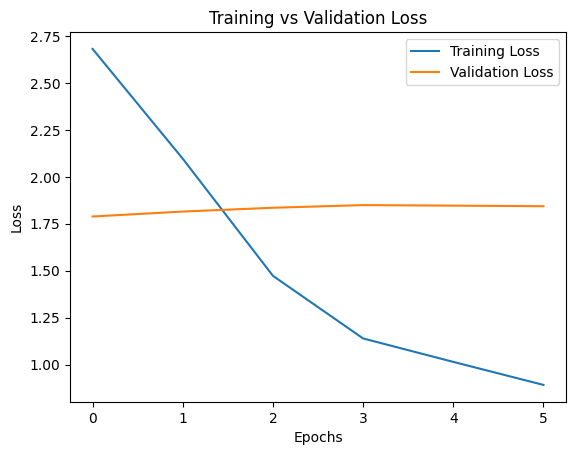

In [63]:
history = model.fit(train_ds,validation_data=val_ds,batch_size=16,epochs=10,callbacks=callbacks)
# Plot loss
plt.figure()
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

# For Test Data


In [64]:
rescale = tf.keras.layers.Rescaling(1./255)
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    labels = "inferred",
    label_mode = "int",
    image_size = (img_height, img_width),
    interpolation = "nearest",
    batch_size = batch_size,
    shuffle = False,
)
class_names = test_ds.class_names
test_ds = test_ds.map(lambda x, y: (rescale(x), y))

Found 30 files belonging to 6 classes.


In [65]:
test_loss,test_accuracy = model.evaluate(test_ds)
print(f"Test Loss:{test_loss:.4f}")
print(f"Test accuracy:{test_accuracy:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.1667 - loss: 1.8178
Test Loss:1.8178
Test accuracy:0.1667


In [66]:
models.save_model(model,'Worksheet_6.h5')
loaded_model = models.load_model('Worksheet_6.h5')

In [67]:
predictions = loaded_model.predict(test_ds)
predicted_labels =np.argmax(predictions,axis=1)

true_labels = np.concatenate([y for x, y in test_ds], axis=0)
print(predicted_labels.shape)
print(f"Predicted label for image : {predicted_labels[0]}")
print(f"True label for image : {true_labels[0]}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
(30,)
Predicted label for image : 4
True label for image : 0


In [68]:
print(classification_report(true_labels, predicted_labels, target_names=class_names))

              precision    recall  f1-score   support

        acai       0.00      0.00      0.00         5
     cupuacu       0.00      0.00      0.00         5
    graviola       0.00      0.00      0.00         5
     guarana       0.00      0.00      0.00         5
     pupunha       0.17      1.00      0.29         5
      tucuma       0.00      0.00      0.00         5

    accuracy                           0.17        30
   macro avg       0.03      0.17      0.05        30
weighted avg       0.03      0.17      0.05        30



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [69]:
base_model = VGG16(weights='imagenet',include_top=False,input_shape=(224,224,3))

In [70]:
for layer in base_model.layers:
    layer.trainable = False

In [71]:
x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(1024,activation='relu')(x)
x = layers.Dense(6,activation='softmax')(x)

In [72]:
tl_model =  Model(inputs=base_model.input,outputs=x)

In [73]:
tl_model.compile(optimizer=Adam(),loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [74]:
history_tl = tl_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=callbacks
)

Epoch 1/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13s/step - accuracy: 0.1551 - loss: 1.8883 
Epoch 1: val_loss improved from 1.78869 to 1.69837, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
3/3 ━━━━━━━━━━━━━━━━━━━━ 69s 20s/step - accuracy: 0.1528 - loss: 1.9155 - val_accuracy: 0.3333 - val_loss: 1.6984
Epoch 2/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13s/step - accuracy: 0.4537 - loss: 1.5375 
Epoch 2: val_loss did not improve from 1.69837
3/3 ━━━━━━━━━━━━━━━━━━━━ 65s 20s/step - accuracy: 0.4861 - loss: 1.5116 - val_accuracy: 0.3889 - val_loss: 1.8559
Epoch 3/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14s/step - accuracy: 0.5764 - loss: 1.3649 
Epoch 3: val_loss did not improve from 1.69837
3/3 ━━━━━━━━━━━━━━━━━━━━ 64s 21s/step - accuracy: 0.5417 - loss: 1.3818 - val_accuracy: 0.3889 - val_loss: 1.7407
Epoch 4/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14s/step - accuracy: 0.6441 - loss: 1.1929 
Epoch 4: val_loss improved from 1.69837 to 1.43519, saving model to best_model.keras

Epoch 4: 

In [75]:
cnn_loss, cnn_acc = model.evaluate(val_ds)
tl_loss, tl_acc = tl_model.evaluate(val_ds)

print("CNN Accuracy:", cnn_acc)
print("Transfer Learning Accuracy:", tl_acc)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 768ms/step - accuracy: 0.2222 - loss: 1.7887
1/1 ━━━━━━━━━━━━━━━━━━━━ 13s 13s/step - accuracy: 0.5556 - loss: 1.2992
CNN Accuracy: 0.2222222238779068
Transfer Learning Accuracy: 0.5555555820465088


In [76]:
y_true = []
y_pred = []

for images, labels in val_ds:
    preds = tl_model.predict(images)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

print(classification_report(y_true, y_pred, target_names=class_names))

1/1 ━━━━━━━━━━━━━━━━━━━━ 13s 13s/step
              precision    recall  f1-score   support

        acai       0.00      0.00      0.00         1
     cupuacu       0.50      1.00      0.67         2
    graviola       0.67      0.67      0.67         3
     guarana       0.60      0.60      0.60         5
     pupunha       0.33      0.25      0.29         4
      tucuma       0.67      0.67      0.67         3

    accuracy                           0.56        18
   macro avg       0.46      0.53      0.48        18
weighted avg       0.52      0.56      0.53        18



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [77]:
for images, labels in val_ds.take(1):
    preds = tl_model.predict(images)
    preds = np.argmax(preds, axis=1)

    for i in range(5):
        print("True:", class_names[labels[i]])
        print("Pred:", class_names[preds[i]])
        print("----")

1/1 ━━━━━━━━━━━━━━━━━━━━ 13s 13s/step
True: guarana
Pred: guarana
----
True: graviola
Pred: pupunha
----
True: cupuacu
Pred: cupuacu
----
True: guarana
Pred: cupuacu
----
True: graviola
Pred: graviola
----
